# Diagnóstico Operacional e Análise Exploratória (EDA)

Este notebook tem como objetivo diagnosticar as causas raízes da queda de performance da operação logística, com foco nos KPIs de On-Time Delivery (OTD), Taxa de Cancelamento e Margem Unitária.

### Escopo da Auditoria
Para garantir a integridade da análise e evitar viés estatístico gerado por lacunas de sistema, o dataset tratado foi submetido a filtros de escopo restritos:

* **Filtro Geográfico:** A análise está isolada exclusivamente na **Cidade 11**, polo de estudo deste case.
* **Filtro Temporal:** Foram excluídos meses com anomalias, dados parciais ou falhas de tracking (Setembro, Novembro e Dezembro de 2025). O diagnóstico compara o mês estável de **Outubro/2025** contra **Janeiro/2026** 

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


# Setup de estilo para os gráficos
sns.set_theme(style="whitegrid")

In [48]:
processed_path = Path("../data/processed/05_BASE_TRATADA_PYTHON.csv")
df = pd.read_csv(processed_path)

df['data'] = pd.to_datetime(df['data'])
df['mes'] = df['data'].dt.strftime('%Y-%m')

# Flags de Status
df['cancelada_flag'] = (df['status'] == 'Cancelada').astype(int)
df['insucesso_flag'] = (df['status'] == 'Insucesso').astype(int)

# Calculando o Custo por KM
df['custo_por_km'] = np.where(df['km'] > 0, df['custo_operacional'] / df['km'], 0)

print(f"Base carregada e features criadas. Volume: {len(df)} linhas.")

Base carregada e features criadas. Volume: 52988 linhas.


In [49]:
# Aplicando o filtro da regra de negócio (Apenas Cidade 11 e remoção de meses sem lacunas)
df_escopo = df[(df['cidade_id'] == 11) & (df['mes'].isin(['2025-10', '2026-01']))].copy()

print(f"Linhas após filtro: {len(df_escopo)}")

Linhas após filtro: 13315


In [50]:
# Calcular p90
def p90(x):
    return x.quantile(0.90)

# Calculando métricas
kpis_mes = df_escopo.groupby('mes').agg(
    Volume=('id_pedido', 'count'),
    OTD=('otd_flag', 'mean'),
    Cancelamentos=('cancelada_flag', 'mean'),
    Insucessos=('insucesso_flag', 'mean'),
    Tempo_Total=('tempo_total_min', 'mean'),
    Tempo_Aceite=('tempo_aceite_min', 'mean'),
    Tempo_Chegada_Origem=('tempo_chegada_origem_min', 'mean'),
    Tempo_Espera_Origem=('tempo_espera_origem_min', 'mean'),
    Tempo_Deslocamento=('tempo_deslocamento_min', 'mean'),
    Custo_Operacional=('custo_operacional', 'mean'),
    Custo_por_KM=('custo_por_km', 'mean'),
    Media_evento_flag=('evento_flag', 'mean'),
    Soma_valor_dinamica=('valor_dinamica', 'sum'),
    P90_tempo_total=('tempo_total_min', p90)
).reset_index()

In [51]:
# Criando uma cópia para não alterar os números originais
tabela_final = kpis_mes.copy()

# Formatações
cols_perc = ['OTD', 'Cancelamentos', 'Insucessos', 'Media_evento_flag']
for col in cols_perc:
    tabela_final[col] = (tabela_final[col] * 100).round(2).astype(str).str.replace('.', ',') + '%'

cols_moeda = ['Custo_Operacional', 'Custo_por_KM']
for col in cols_moeda:
    tabela_final[col] = 'R$ ' + tabela_final[col].round(2).astype(str).str.replace('.', ',')

tabela_final['Soma_valor_dinamica'] = 'R$ ' + tabela_final['Soma_valor_dinamica'].round(2).astype(str).str.replace('.', ',')

cols_tempo = ['Tempo_Total', 'Tempo_Aceite', 'Tempo_Chegada_Origem', 'Tempo_Espera_Origem', 'Tempo_Deslocamento', 'P90_tempo_total']
for col in cols_tempo:
    tabela_final[col] = tabela_final[col].round(2).astype(str).str.replace('.', ',')

tabela_final.columns = [
    'Mês', 'Volume', 'OTD', 'Cancelamentos', 'Insucessos', 'Tempo Total', 
    'Tempo Aceite', 'Tempo Chegada Origem', 'Tempo Espera Origem', 
    'Tempo Deslocamento', 'Custo Operacional', 'Custo por KM', 
    'Média de evento_flag', 'Soma de valor_dinamica', 'P90 tempo total'
]

display(tabela_final)

,Mês,Volume,OTD,Cancelamentos,Insucessos,Tempo Total,Tempo Aceite,Tempo Chegada Origem,Tempo Espera Origem,Tempo Deslocamento,Custo Operacional,Custo por KM,Média de evento_flag,Soma de valor_dinamica,P90 tempo total
0,2025-10,6226,"88,02%","6,99%","1,4%","20,87","2,84","4,52","0,92","12,59","R$ 8,7","R$ 6,89","17,15%",R$ 1834,"45,87"
1,2026-01,7089,"88,07%","7,28%","1,42%","21,09","2,69","4,65","0,97","12,79","R$ 8,17","R$ 6,36","0,0%",R$ 0,"46,51"


### Principais Ofensores


* **Evolução dos KPIs Principais:** O indicador que apresentou a piora mais relevante foi a **Taxa de Cancelamento**, que subiu de 6,99% (Out/25) para 7,28% (Jan/26), representando um aumento relativo de aproximadamente 4,1%. Em contrapartida, o OTD manteve-se estagnado com uma leve melhora marginal (de 88,02% para 88,07%).

* **O Fator Dinâmica (Eventos):** A piora na retenção de pedidos em Janeiro/2026 coincide com a suspensão total dos pagamentos de dinâmica. Enquanto o mês de baseline (Outubro/2025) contou com um investimento de **R$ 1.834,00** em eventos, Janeiro operou com repasse zerado para a frota.

* **Gargalos de Tempo:** O principal detrator do SLA é o tempo de **Deslocamento**. No período crítico, ele consumiu em média **12,79 minutos**, o que representa cerca de 60% de todo o tempo total gasto no ciclo de vida do pedido.

In [52]:
# --- OTD E CANCELAMENTO POR MODALIDADE E CANAL ---

# 1. Agrupamento Total por Modalidade
df_mod = df_escopo.groupby('modalidade').agg(
    Qntd=('id_pedido', 'count'),
    OTD=('otd_flag', 'mean'),
    CANCELAMENTO=('cancelada_flag', 'mean'),
    SLA_MIN_Medio=('sla_min', 'mean')
).reset_index()
df_mod.insert(1, 'canal', ' TOTAL') # Adicionamos espaço antes de TOTAL para ele ficar no topo ao ordenar

# 2. Agrupamento por Canal dentro da Modalidade
df_canal = df_escopo.groupby(['modalidade', 'canal']).agg(
    Qntd=('id_pedido', 'count'),
    OTD=('otd_flag', 'mean'),
    CANCELAMENTO=('cancelada_flag', 'mean'),
    SLA_MIN_Medio=('sla_min', 'mean')
).reset_index()

tabela_dinamica = pd.concat([df_mod, df_canal]).sort_values(by=['modalidade', 'canal'])

tabela_formatada = tabela_dinamica.copy()
tabela_formatada['OTD'] = (tabela_formatada['OTD'] * 100).round(2).astype(str).str.replace('.', ',') + '%'
tabela_formatada['CANCELAMENTO'] = (tabela_formatada['CANCELAMENTO'] * 100).round(2).astype(str).str.replace('.', ',') + '%'
tabela_formatada['SLA_MIN_Medio'] = tabela_formatada['SLA_MIN_Medio'].round(2).astype(str).str.replace('.', ',')
tabela_formatada['modalidade'] = tabela_formatada.apply(
    lambda row: row['modalidade'] if row['canal'] == ' TOTAL' else '', 
    axis=1
)

tabela_formatada.columns = ['Modalidade', 'Canal', 'Qntd.', 'OTD', 'CANCELAMENTO', 'SLA_MIN Médio']

display(tabela_formatada.style.hide(axis="index"))

Modalidade,Canal,Qntd.,OTD,CANCELAMENTO,SLA_MIN Médio
Econômica,TOTAL,5623,"89,72%","6,38%","60,0"
,App,4206,"90,39%","5,92%","60,0"
,Integrado,1141,"87,55%","7,71%","60,0"
Expressa,TOTAL,1606,"84,74%","5,79%","40,0"
,App,1231,"84,81%","6,42%","40,0"
,Integrado,281,"84,7%","4,27%","40,0"
Integrada,TOTAL,2195,"89,11%","6,2%","55,0"
,App,1540,"89,03%","6,43%","55,0"
,Integrado,534,"88,39%","6,18%","55,0"
Manual,TOTAL,3891,"86,38%","9,33%","70,0"


## 2. Diagnóstico de Gargalos: Tempo, Distância e Eventos


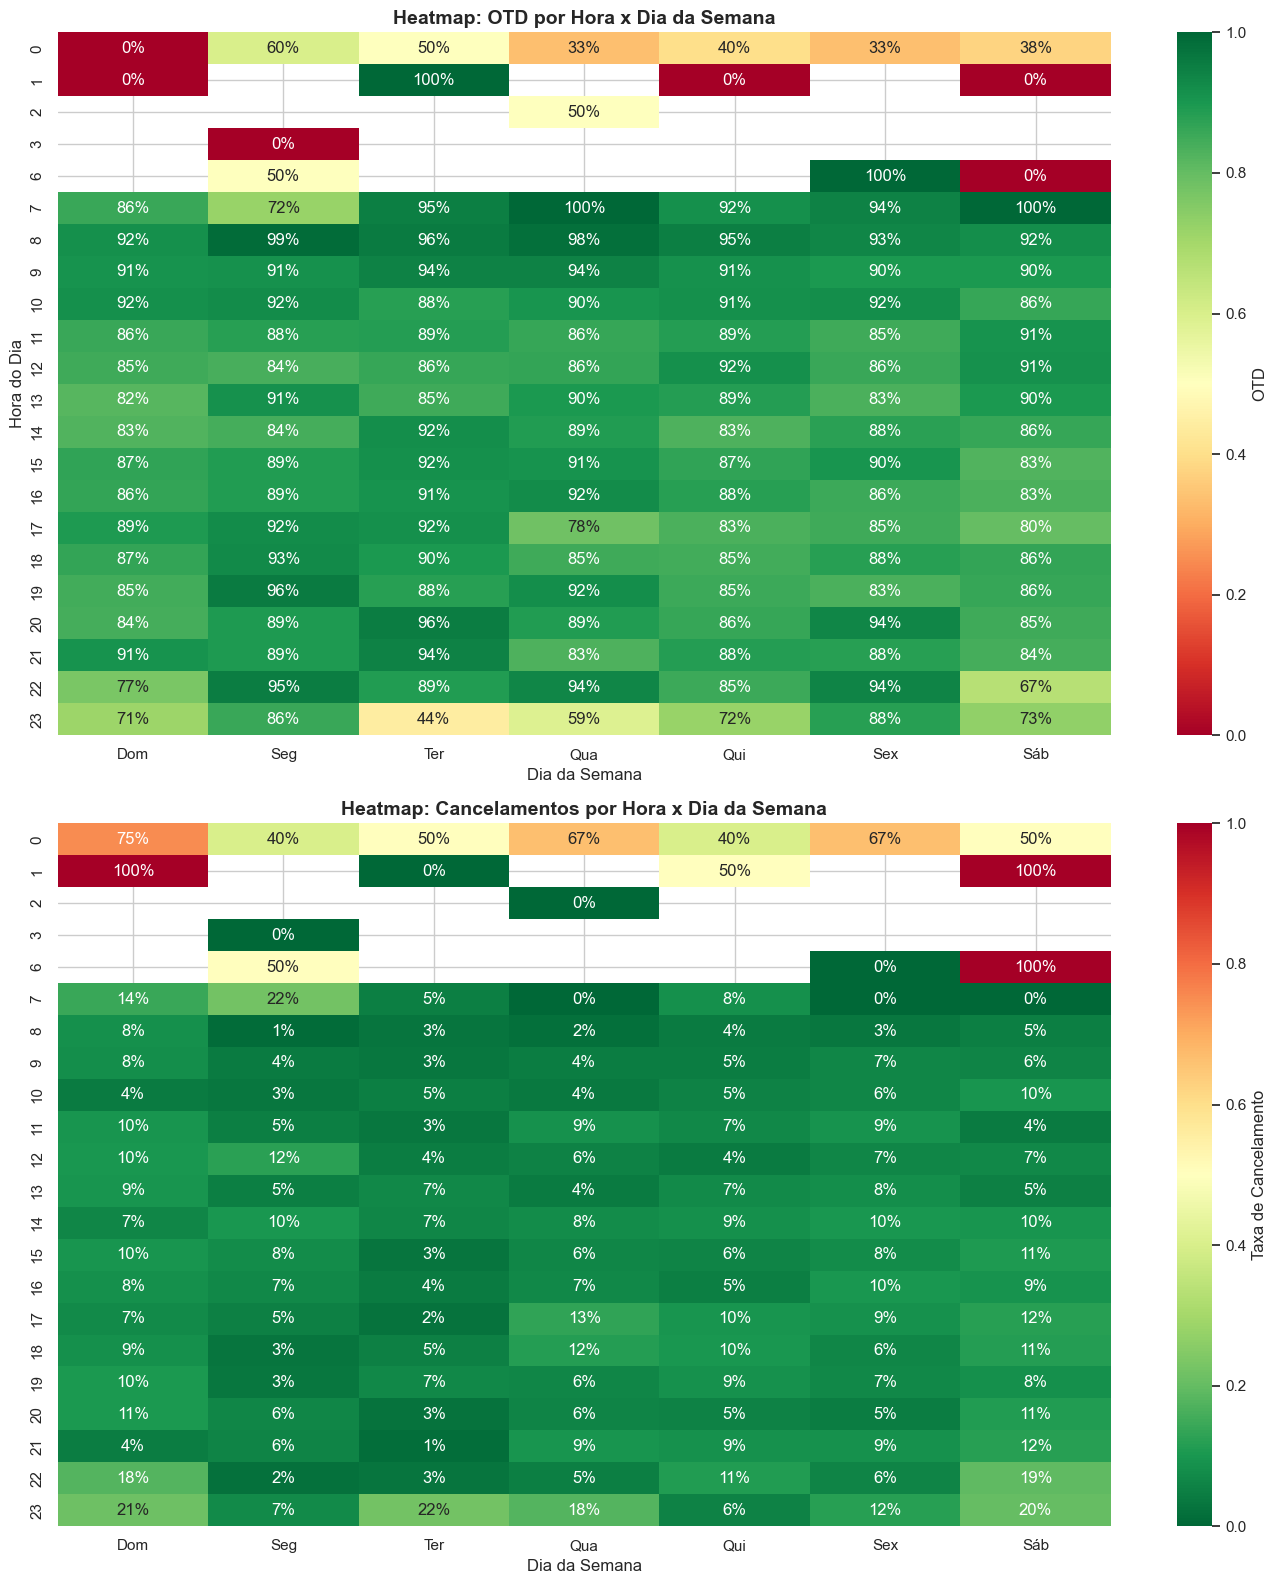

In [53]:
# --- HEATMAPS DE OTD E CANCELAMENTO ---

# Ordem dos dias da semana
dias_ordem = ['Dom', 'Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb']
df_escopo['dia_semana'] = pd.Categorical(df_escopo['dia_semana'], categories=dias_ordem, ordered=True)

# Criando Pivot Tables 
pivot_otd = df_escopo.pivot_table(index='hora_int', columns='dia_semana', values='otd_flag', aggfunc='mean')
pivot_cx = df_escopo.pivot_table(index='hora_int', columns='dia_semana', values='cancelada_flag', aggfunc='mean')

# Configurando a posição da figura 
fig, axes = plt.subplots(2, 1, figsize=(14, 16))

# Heatmap de OTD 
sns.heatmap(pivot_otd, annot=True, fmt=".0%", cmap="RdYlGn", ax=axes[0], cbar_kws={'label': 'OTD'})
axes[0].set_title('Heatmap: OTD por Hora x Dia da Semana', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Dia da Semana')
axes[0].set_ylabel('Hora do Dia')

# Heatmap de Cancelamento
sns.heatmap(pivot_cx, annot=True, fmt=".0%", cmap="RdYlGn_r", ax=axes[1], cbar_kws={'label': 'Taxa de Cancelamento'})
axes[1].set_title('Heatmap: Cancelamentos por Hora x Dia da Semana', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Dia da Semana')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [54]:
# --- TURNO E FAIXA DE KM ---

# 1. Tabela por Turno
turnos_ordem = ['Manhã', 'Tarde', 'Noite']
df_escopo['turno'] = pd.Categorical(df_escopo['turno'], categories=turnos_ordem, ordered=True)

df_turno = df_escopo.groupby('turno').agg(
    Qntd=('id_pedido', 'count'),
    OTD=('otd_flag', 'mean'),
    CANCELAMENTO=('cancelada_flag', 'mean'),
    P90_tempo_total=('tempo_total_min', p90)
).reset_index()


# Criando a faixa de KM 
bins = [-np.inf, 3, 7, 12, np.inf] # Limites numéricos (até 3, de 3 a 7, de 7 a 12, mais que 12)
labels = ['0-3', '3-7', '7-12', '12+']
df_escopo['faixa_km'] = pd.cut(df_escopo['km'], bins=bins, labels=labels)

# Tabela por KM
df_km = df_escopo.groupby('faixa_km', observed=False).agg(
    Qntd=('id_pedido', 'count'),
    OTD=('otd_flag', 'mean'),
    CANCELAMENTO=('cancelada_flag', 'mean'),
    P90_tempo_total=('tempo_total_min', p90)
).reset_index()

# Função para formatar tabelas
def formatar_tabela_resumo(df_in):
    df_out = df_in.copy()
    df_out['OTD'] = (df_out['OTD'] * 100).round(1).astype(str).str.replace('.', ',') + '%'
    df_out['CANCELAMENTO'] = (df_out['CANCELAMENTO'] * 100).round(1).astype(str).str.replace('.', ',') + '%'
    df_out['P90_tempo_total'] = df_out['P90_tempo_total'].round(0).astype(int)
    return df_out

print("--- ANÁLISE POR TURNO ---")
display(formatar_tabela_resumo(df_turno).style.hide(axis="index"))

print("\n--- ANÁLISE POR KM ---")
display(formatar_tabela_resumo(df_km).style.hide(axis="index"))

--- ANÁLISE POR TURNO ---


turno,Qntd,OTD,CANCELAMENTO,P90_tempo_total
Manhã,3781,"90,1%","5,9%",42
Tarde,5752,"87,1%","7,5%",49
Noite,3782,"87,4%","7,8%",45



--- ANÁLISE POR KM ---


faixa_km,Qntd,OTD,CANCELAMENTO,P90_tempo_total
0-3,10046,"94,0%","3,8%",33
3-7,2709,"72,5%","16,3%",69
7-12,487,"58,5%","22,0%",95
12+,73,"46,6%","21,9%",119


In [55]:
# --- EVENTO VS NÃO-EVENTO ---

df_evento = df_escopo.groupby('evento_flag').agg(
    OTD=('otd_flag', 'mean'),
    CANCELAMENTO=('cancelada_flag', 'mean'),
    VALOR_DINAMICA=('valor_dinamica', 'mean'),
    P90_tempo_total=('tempo_total_min', p90)
).reset_index()

# Formatando
df_evento_fmt = df_evento.copy()
df_evento_fmt['OTD'] = (df_evento_fmt['OTD'] * 100).round(0).astype(int).astype(str) + '%'
df_evento_fmt['CANCELAMENTO'] = (df_evento_fmt['CANCELAMENTO'] * 100).round(0).astype(int).astype(str) + '%'
df_evento_fmt['VALOR_DINAMICA'] = df_evento_fmt['VALOR_DINAMICA'].round(2)
df_evento_fmt['P90_tempo_total'] = df_evento_fmt['P90_tempo_total'].round(3)

print("--- ANÁLISE DE EVENTO VS. NÃO-EVENTO ---")
display(df_evento_fmt.style.hide(axis="index"))

--- ANÁLISE DE EVENTO VS. NÃO-EVENTO ---


evento_flag,OTD,CANCELAMENTO,VALOR_DINAMICA,P90_tempo_total
0,88%,7%,0.000000,45.840000
1,87%,8%,1.720000,50.993000


#### Problemas Identificados na Segmentação (Ofensores)

1. **Distância Elevada (O maior detrator):** A performance despenca em rotas longas. Em entregas de 7 a 12 km, o OTD cai para **58,5%** e os cancelamentos saltam para 22,0%. O cenário é ainda mais crítico na faixa de **12+ km**, onde o OTD retrai para **46,6%** e o tempo P90 chega a **119 minutos** (quase quadruplicando o tempo das rotas curtas de até 3 km).

2. **Ofensores por Turno:** O **Turno da Tarde** concentra o maior gargalo logístico: possui o maior volume absoluto da operação (5.752 pedidos), o maior tempo P90 (49 minutos) e o menor OTD da grade (87,1%). Paralelamente, o **Turno da Noite** apresenta a maior propensão a falhas, liderando a taxa de cancelamentos com **7,8%**.

3. **Gargalos por Modalidade:** Confirmando a análise de canais, a **Modalidade Manual** é um ofensor crítico de retenção, apresentando uma taxa de cancelamento severa de **9,33%** para um alto volume de entrada.